In [1]:
import os
import sys
sys.path.append(os.path.abspath('..'))

import numpy as np
import tensorflow as tf
import json


from src.networks.DecoderPINN import PINN, compute_residual 
from src.physics.physics import get_M_dynamic
from src.visualization.pdeplots import get_eval_grid,plot_residual_map, plot_parametric_pinn_solution, evaluate_and_plot_parametric_scars
from src.utils.metrics import compute_and_print_metrics
from src.hyperparameters import hypers_parametric as h
from src.visualization.pdeplots import N_GRID

tf.keras.backend.set_floatx('float64')
number_type = tf.float64

U_SCALE = float(np.load('data/models/u_scale_var.npy')[0])

model = PINN(h.N_NEURONS_DECODER, U_SCALE)
model(tf.zeros((1,4), dtype=number_type)) # (x, y, cx, cy)

with open('data/models/current_pipeline_id.json', 'r') as f:
    pipeline_id = json.load(f)['latest_id']

pretrained_weights = f'data/models/weights/{pipeline_id}_decoder_lbfgs.weights.h5'
model.load_weights(pretrained_weights)
print(f"Model loaded: {pipeline_id} ")

2026-09-10 16:42:39.421249: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-10 16:42:39.436023: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789051359.451532  157056 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789051359.457059  157056 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1789051359.473104  157056 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Model loaded: 20260910_162018 


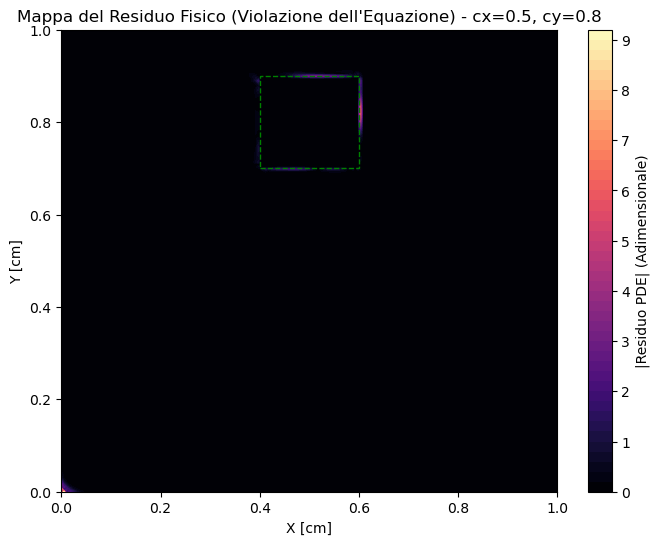

In [2]:
# Position of the scar (CHANGE TO TEST OTHER CONFIGS)
cx_test = 0.5
cy_test = 0.8
scar_edge = 0.2

N_res = 200
X_res, Y_res, X_res_tensor = get_eval_grid(N_res, cx_test, cy_test)
pde_res = compute_residual(model, X_res_tensor, get_M_dynamic)
Residual_Grid = np.abs(pde_res.numpy()).reshape(N_res, N_res)

plot_residual_map(X_res, Y_res, Residual_Grid, cx_test, cy_test,scar_edge)

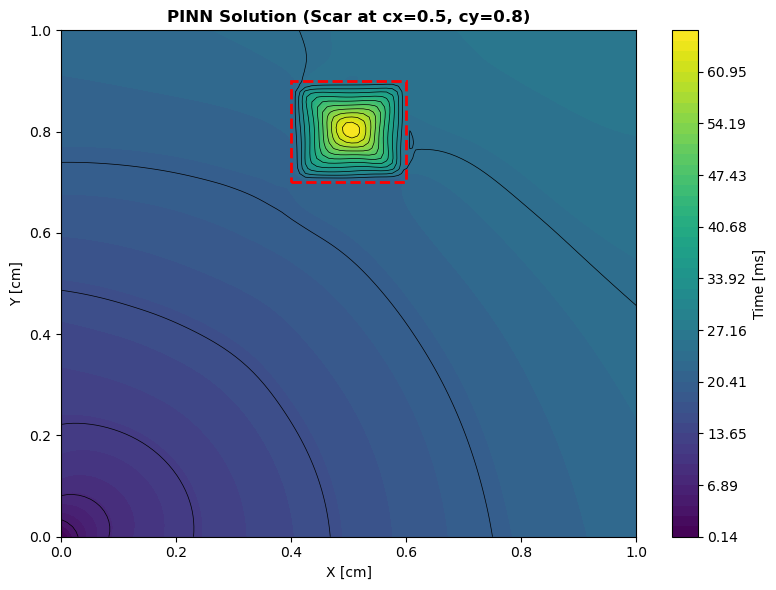

In [3]:
N_fem = N_GRID
X_fem, Y_fem, X_fem_tensor = get_eval_grid(N_fem, cx_test, cy_test)

u_pinn = model(X_fem_tensor).numpy().flatten() * U_SCALE
U_pinn2D = u_pinn.reshape(N_fem, N_fem) * 1000.0

plot_parametric_pinn_solution(
    X_fem=X_fem, 
    Y_fem=Y_fem, 
    U_pinn2D=U_pinn2D, 
    cx_test=cx_test, 
    cy_test=cy_test,
)

In [4]:
data_test = np.load('data/fem/fem_parametric_test_grid.npz')
coords_test = data_test['coords']   # array (N, 4)
u_fem = data_test['values'].flatten()

coords_test_tensor = tf.convert_to_tensor(coords_test, dtype=number_type)
u_pinn = model(coords_test_tensor).numpy().flatten() * U_SCALE

test_mse, test_mae = compute_and_print_metrics(u_fem, u_pinn, U_SCALE)


Test MSE (Adimensionale) : 1.380921e-05
Test MAE (Fisico)        : 0.1454 ms


101 different scar configurations in the test set.

Configuration (cx, cy)    | Relative L2 Error 
-----------------------------------------------
Scar at cx=0.20, cy=0.66    | 1.48%
Scar at cx=0.20, cy=0.70    | 1.45%
Scar at cx=0.21, cy=0.35    | 1.44%
Scar at cx=0.21, cy=0.37    | 1.54%
Scar at cx=0.22, cy=0.43    | 1.32%
Scar at cx=0.23, cy=0.41    | 1.25%
Scar at cx=0.24, cy=0.72    | 1.39%
Scar at cx=0.27, cy=0.45    | 1.11%
Scar at cx=0.28, cy=0.76    | 1.43%
Scar at cx=0.28, cy=0.80    | 1.49%
Scar at cx=0.28, cy=0.40    | 1.07%
Scar at cx=0.29, cy=0.54    | 1.07%
Scar at cx=0.29, cy=0.64    | 1.13%
Scar at cx=0.29, cy=0.41    | 1.02%
Scar at cx=0.30, cy=0.38    | 1.11%
Scar at cx=0.31, cy=0.74    | 1.30%
Scar at cx=0.32, cy=0.71    | 1.22%
Scar at cx=0.32, cy=0.70    | 1.12%
Scar at cx=0.33, cy=0.80    | 1.49%
Scar at cx=0.33, cy=0.24    | 1.44%
Scar at cx=0.34, cy=0.26    | 1.33%
Scar at cx=0.35, cy=0.36    | 1.01%
Scar at cx=0.35, cy=0.74    | 1.25%
Scar at cx=0.36, cy=0.50 

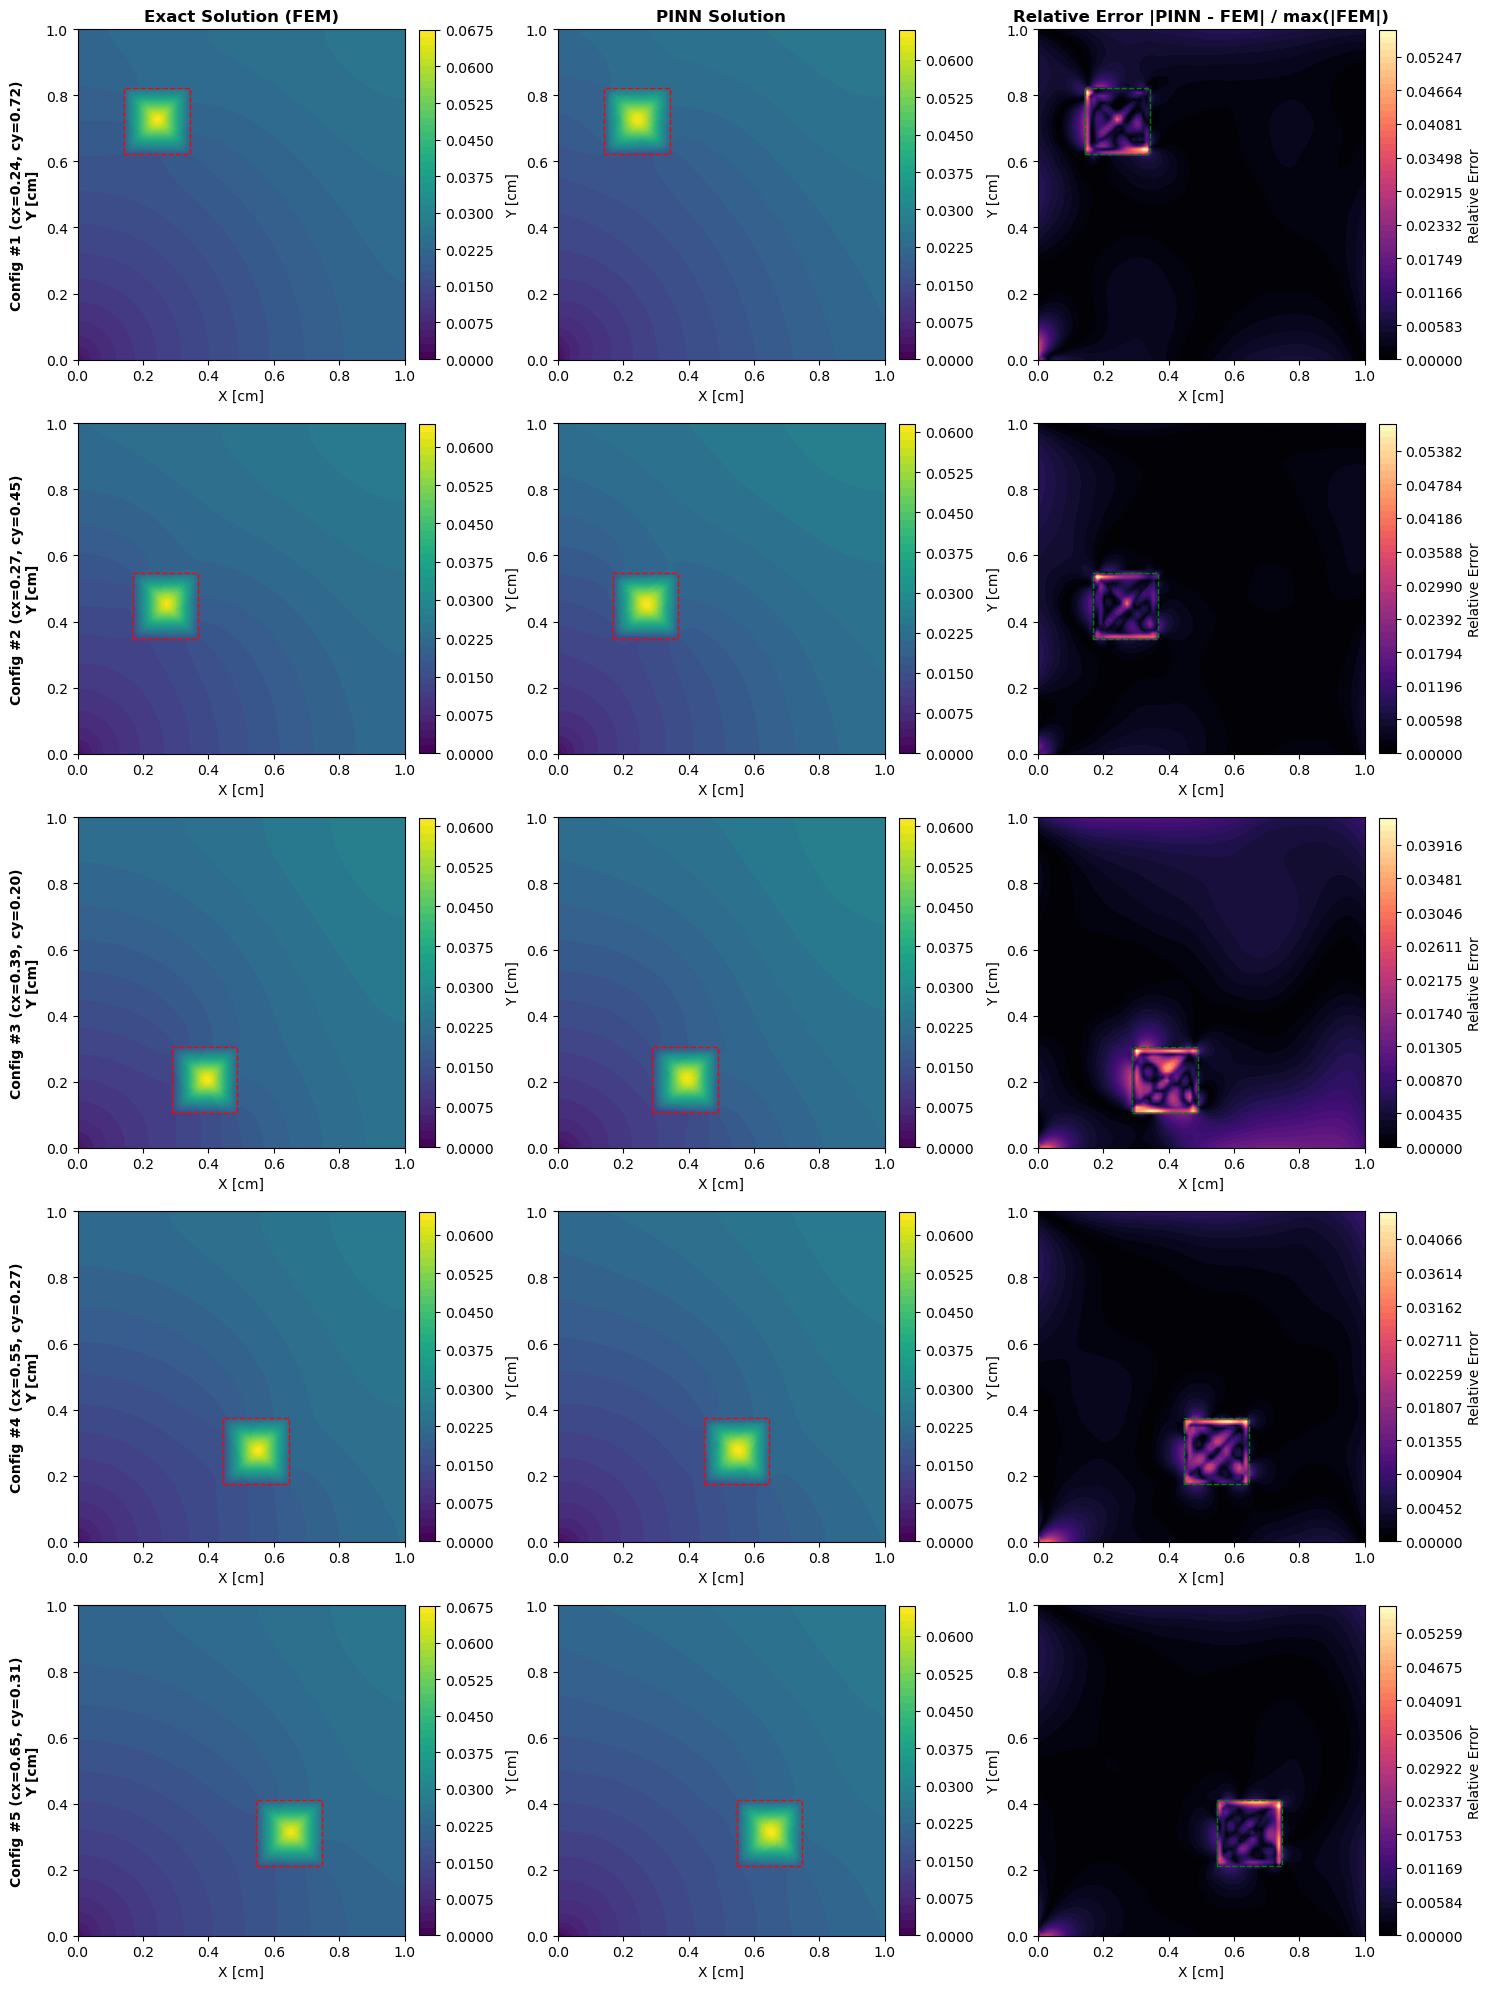

In [5]:
u_fem_all = data_test['values']

evaluate_and_plot_parametric_scars(
    model=model, 
    coords_test=coords_test, 
    u_fem_all=u_fem_all, 
    U_SCALE=U_SCALE, 
    num_to_plot=5,        
    lato_cicatrice=0.2    
)